# MNIST
## 07. Decision Tree with Gini Impurity

In [1]:
from infdsa_mnist import mnist_load_normalized, mnist_output, gini_tree, gini_tree_output, features
import numpy as np

In chapter 7 we explored the decision tree algorithm using a basic threshold split. In this chapter, we will implement a decision tree using the Gini impurity as the splitting criterion. The Gini impurity lets us find the best feature and threshold to split the data at each node of the tree. In the implementation, we will use scikit-learn's `DecisionTreeClassifier` with the criterion set to 'gini' to build our decision tree.

In [2]:
(train_data, test_data) = mnist_load_normalized.load_mnist_normalized()
x_train, y_train = train_data
x_test, y_test = test_data

x_train_flat = mnist_load_normalized.flatten_images(x_train)
x_test_flat = mnist_load_normalized.flatten_images(x_test)

We will be training the tree with the following features:
- None (the tree will automatically use the pixel values as features)
- Chapter 7 features:
    - Dark pixel percentage
    - Symmetry percentage
    - Center point intensity
    - Bounding box aspect ratio
    - Pixel intensity per quadrant
- A mixture of all pixel values and the chapter 7 features

## Training the Decision Tree

In [3]:
dt = gini_tree.train_gini_tree(x_train_flat, y_train)

The `train_gini_tree` function trains a decision tree classifier using the Gini impurity criterion. It takes the flattened training data and the corresponding labels as input and returns the trained decision tree model. The decision tree will automatically determine the best splits for the data based on the Gini impurity. After training the model, we can evaluate its performance on the test set and analyze the results.

## Evaluating the Decision Tree

In [4]:
y_pred = dt.predict(x_test_flat)
acc = gini_tree.accuracy(y_test, y_pred)
cm = gini_tree.create_confusion_matrix(y_test, y_pred)

acc_percentage = acc * 100

Decision Tree Accuracy on MNIST: 88.09 %


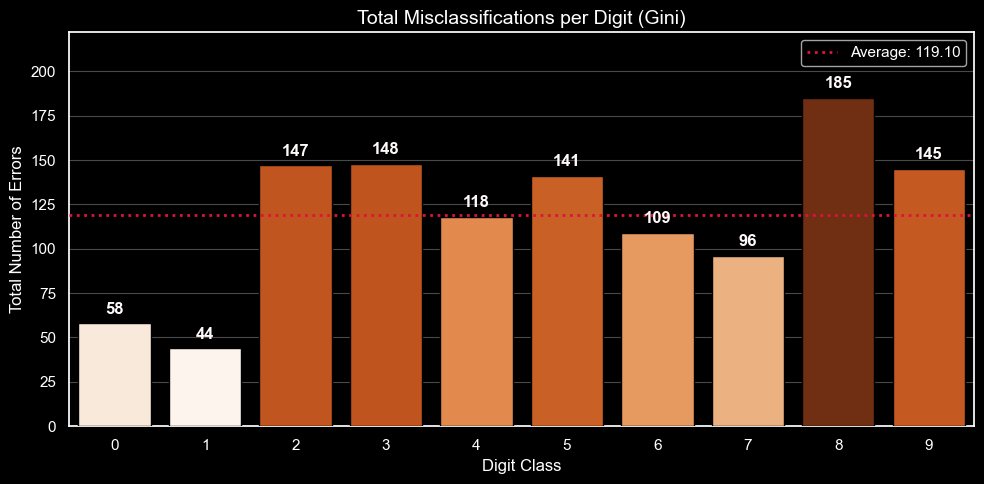

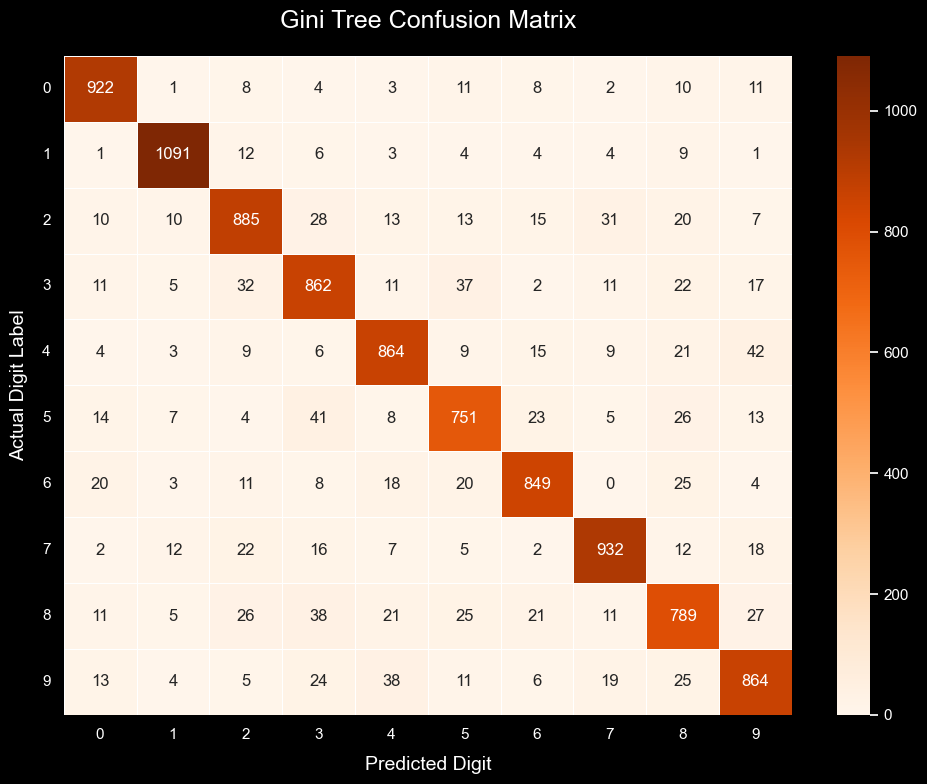

In [5]:
print("Decision Tree Accuracy on MNIST:", acc_percentage, "%")

mnist_output.display_total_errors_barplot(cm, title="Total Misclassifications per Digit (Gini)")
gini_tree_output.display_full_confusion_matrix(cm)

With 88.09% accuracy, the decision tree with Gini impurity has higher accuracy compared to the one we implemented in chapter 7, which measured around 50% on the  embedded system and 56.81% on a computer. Several factors could contribute to this improvement:
- The Gini impurity criterion allows the decision tree to find better splits in the data than the basic threshold method.
- The basic Gini impurity implementation automatically selects all pixel values as features, which provides more information for the tree to make decisions compared to the manually engineered features in chapter 7.

## Displaying the Tree Structure

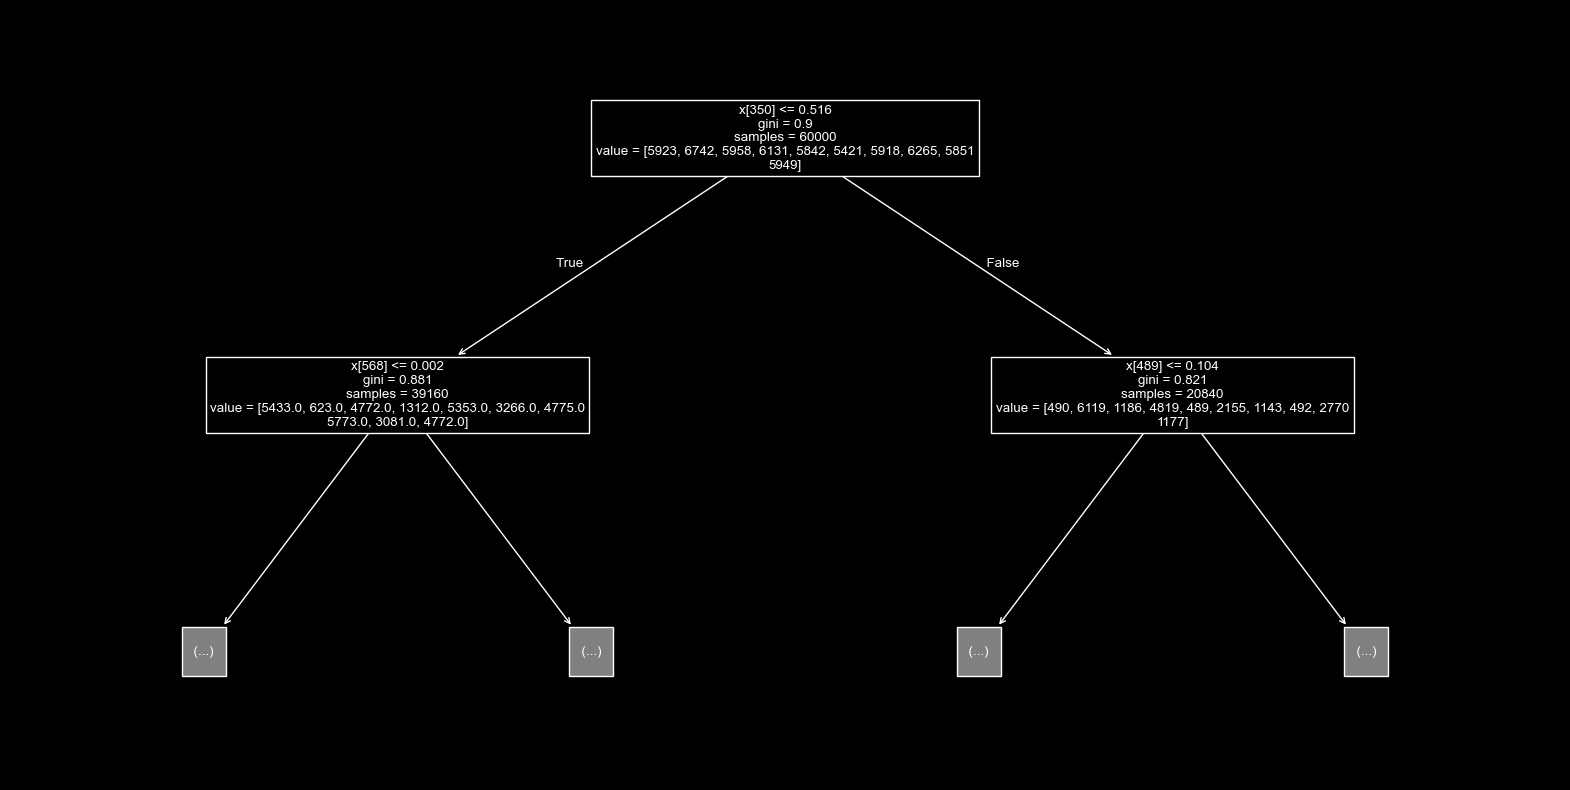

In [6]:
gini_tree_output.display_decision_tree_structure(dt, max_depth=1)

The `display_decision_tree_structure` function visualizes the structure of the decision tree. By setting `max_depth=1`, we can see the top level of the tree, which shows the first split based on the most important feature. This visualization helps us understand how the decision tree is making its decisions and which features are being used for splitting the data at each node.
This is what each of the data points within the blocks represents:
- `x[feature_index] <= threshold`: This is the condition for the split at that node. The tree will check if the value of the specified feature (given by `feature_index`) is less than or equal to the threshold value.
- `gini = value`: This is the Gini impurity of the node. A lower Gini impurity indicates the node is purer, meaning it contains mostly samples of a single class.
- `samples = value`: This is the number of samples that reach that particular node that reach that node.
- `value = [x, y, ...]`: This is the amount of samples belonging to each digit class that reach that node. For example, if the value is `[1000, 0, 0, 0, 0, 0, 0, 0, 0, 0]`, it means that all 1000 samples at that node belong to the digit class '0'. If the value is `[500, 500, 0, 0, 0, 0, 0, 0, 0, 0]`, it means that there are an equal number of samples for digits '0' and '1' at that node.

## Chapter 7 Features

In [7]:
dt_ch7 = gini_tree.train_gini_tree_ch7(x_train, y_train)

x_test_features = np.array([features.extract_features(img) for img in x_test])

y_pred_ch7 = dt_ch7.predict(x_test_features)
acc_ch7 = gini_tree.accuracy(y_test, y_pred_ch7)
cm_ch7 = gini_tree.create_confusion_matrix(y_test, y_pred_ch7)

acc_ch7_percentage = acc_ch7 * 100

Decision Tree Accuracy with Chapter 7 Features on MNIST: 59.68 %


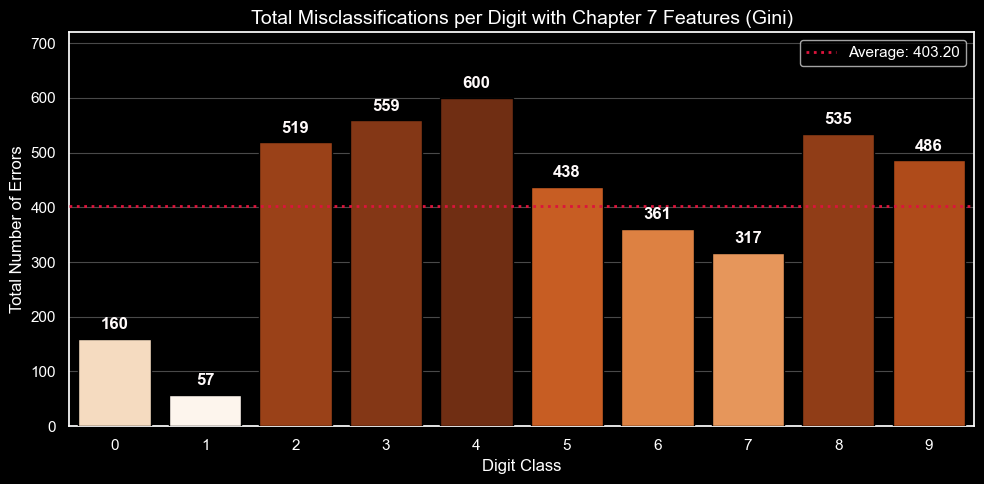

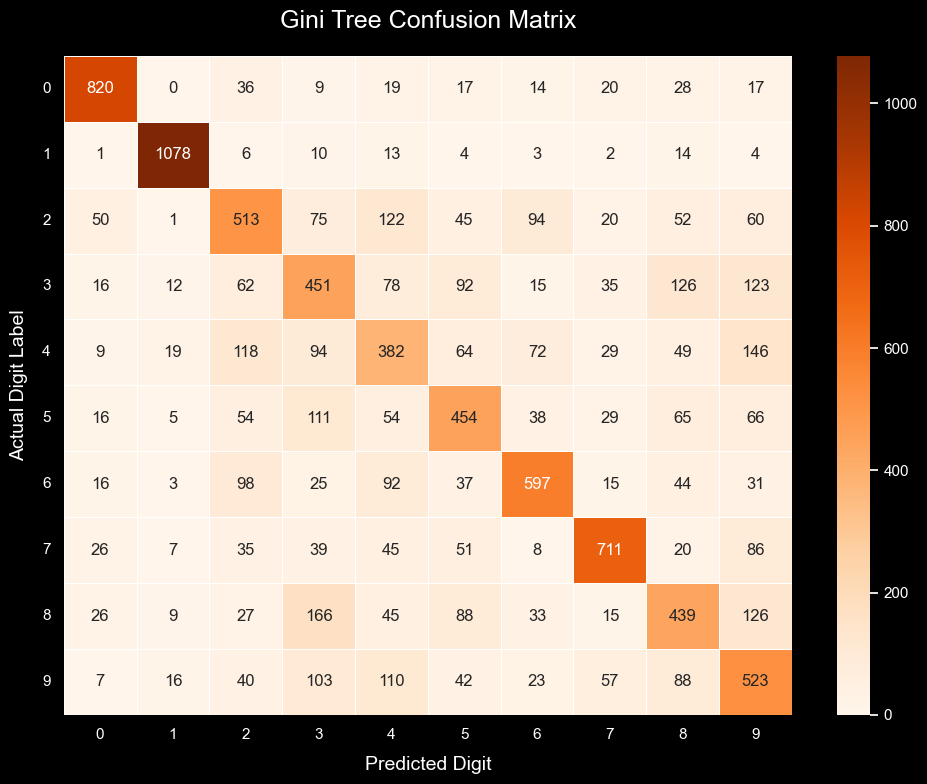

In [8]:
print("Decision Tree Accuracy with Chapter 7 Features on MNIST:", acc_ch7_percentage, "%")
mnist_output.display_total_errors_barplot(cm_ch7, title="Total Misclassifications per Digit with Chapter 7 Features (Gini)")
gini_tree_output.display_full_confusion_matrix(cm_ch7)

As we can see, the decision tree trained with the chapter 7 features scores a total of 59.68% accuracy, which is significantly lower than the 88.09% achieved by the decision tree trained with all pixel data. It is, however, higher than what we achieved using the basic threshold method in chapter 7, both on the embedded system (50%) and on a computer (56.81%). This suggests that while the chapter 7 features do provide some useful information for classification, they are not as effective as using the raw pixel values when combined with the Gini impurity criterion for splitting the data. The splits are better when using Gini impurity, but does not make up for the loss of information from using the engineered features, meaning the features, as we predicted, are the main reason for the lower accuracy compared to using all pixel values.

## Combined Features

In [9]:
dt_combined = gini_tree.train_gini_tree_combined(x_train, y_train)

x_test_combined = np.hstack((x_test_flat, np.array([features.extract_features(img) for img in x_test])))

y_pred_combined = dt_combined.predict(x_test_combined)
acc_combined = gini_tree.accuracy(y_test, y_pred_combined)
cm_combined = gini_tree.create_confusion_matrix(y_test, y_pred_combined)

acc_combined_percentage = acc_combined * 100

Decision Tree Accuracy with Combined Features on MNIST: 88.44999999999999 %


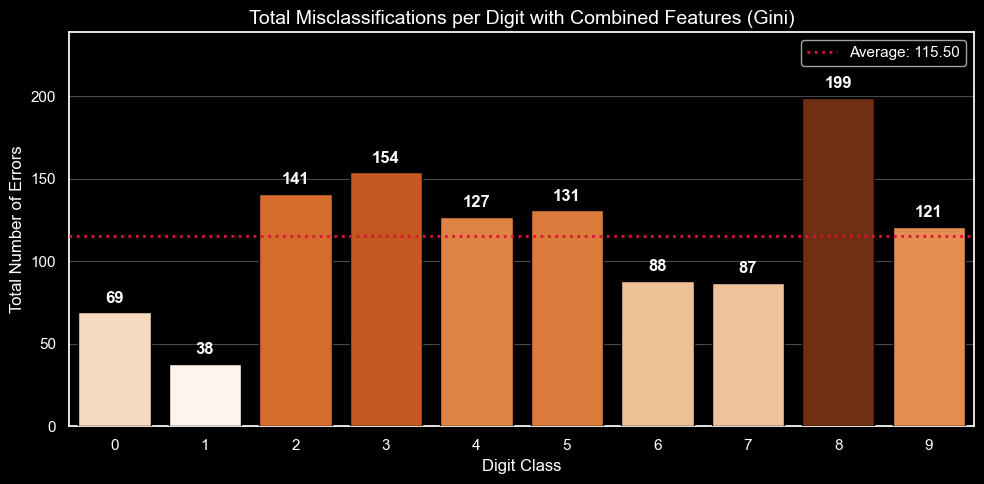

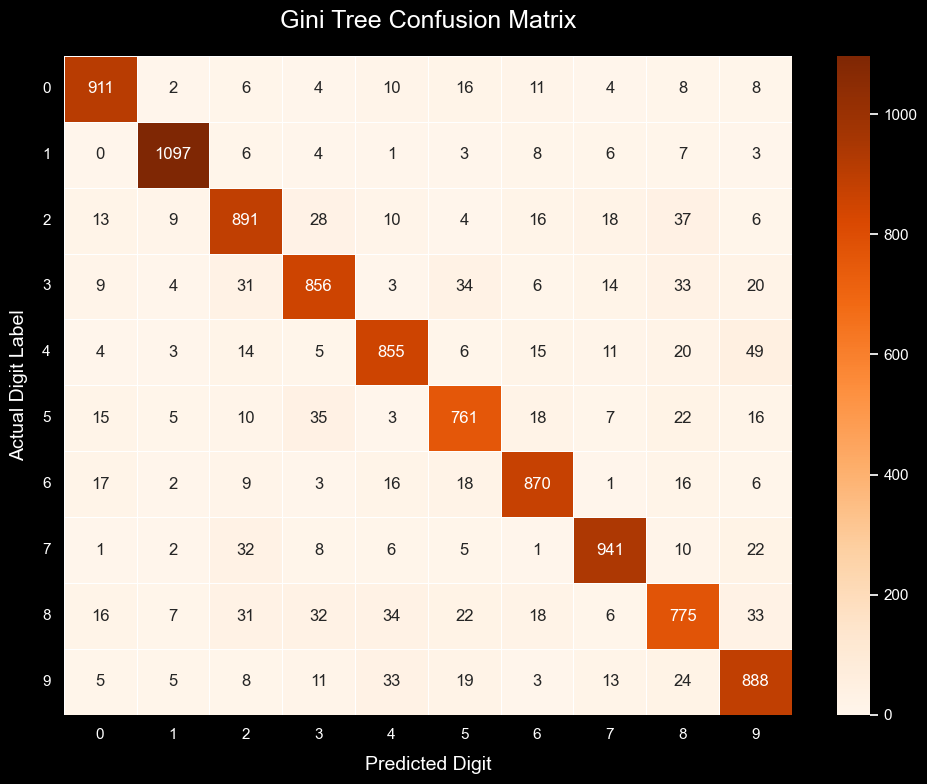

In [10]:
print("Decision Tree Accuracy with Combined Features on MNIST:", acc_combined_percentage, "%")
mnist_output.display_total_errors_barplot(cm_combined, title="Total Misclassifications per Digit with Combined Features (Gini)")
gini_tree_output.display_full_confusion_matrix(cm_combined)

The total accuracy we achieve with the combined features is 88.44999...%, which is slightly higher than the 88.09% we achieved using all pixel values alone. This suggests that while the chapter 7 features do provide some additional information that can help with classification, the improvement is marginal when combined with the raw pixel values. The Gini impurity criterion allows the decision tree to effectively use both the raw pixel values and the engineered features, but the raw pixel values still carry the most significant information for classification.
In addition, the extra time it takes to design the engineered features might not be worth the small increase in accuracy, especially if we consider the computational cost of extracting those features. In practice, it might be more efficient to use the raw pixel values with a well-tuned decision tree rather than investing time in feature engineering for this particular dataset.